In [1]:
%load_ext autoreload
%autoreload 2

import os, h5py, math
import numpy as np
import healpy as hp
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy import stats
from tqdm import tqdm

from msfm.grid_pipeline import GridPipeline
from msfm.utils import files, power_spectra, catalog, observation, buzzard

2026-02-13 02:57:44.370872: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-13 02:57:44.370905: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-13 02:57:44.526619: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-13 02:57:44.912532: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-13 02:58:03.989712: W tensorflow/compiler/tf2

In [2]:
conf = "/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v16/default.yaml"
conf = files.load_config(conf)

n_side = conf["analysis"]["n_side"]
n_pix = conf["analysis"]["n_pix"]
apply_norm = False

# assume they're all identical
mask_dv = files.get_tomo_dv_masks(conf)["metacal"].astype(bool)[:,0]
mask = files.get_tomo_masks(conf)["metacal"].astype(bool)[:,0]

# external

## DES Y3

In [3]:
wl_gamma_map, _ = catalog.build_metacal_map_from_cat(conf)
gc_count_map = catalog.build_maglim_map_from_cat(conf)

apply_maglim_sys_map = True
obs_label = "DES Y3"

26-02-13 02:58:57   catalog.py WAR   Compare with Table 1 in https://arxiv.org/pdf/2105.13543 
26-02-13 02:58:57   catalog.py INF   Metacalibration bin 1 
26-02-13 02:58:57   catalog.py INF   N_gal = 24940465, n_eff = 1.476 [arcmin^-2] 
26-02-13 02:58:57   catalog.py INF   mean(e1) = 3.22e-04, mean(e2) = 1.60e-04 
26-02-13 02:58:57   catalog.py INF   sigma_e (H12) = 0.245, sigma_e (C13) = 0.187 
26-02-13 02:59:02   catalog.py INF   mean(R_gamma) = 0.7636 
26-02-13 02:59:05   catalog.py INF   z_mean (DNF) = 0.3305 
26-02-13 02:59:10   catalog.py INF   Metacalibration bin 2 
26-02-13 02:59:10   catalog.py INF   N_gal = 25280405, n_eff = 1.479 [arcmin^-2] 
26-02-13 02:59:10   catalog.py INF   mean(e1) = 3.36e-04, mean(e2) = 3.74e-05 
26-02-13 02:59:11   catalog.py INF   sigma_e (H12) = 0.265, sigma_e (C13) = 0.191 
26-02-13 02:59:12   catalog.py INF   mean(R_gamma) = 0.7182 
26-02-13 02:59:12   catalog.py INF   z_mean (DNF) = 0.5133 
26-02-13 02:59:19   catalog.py INF   Metacalibration bi

## Buzzard

In [4]:
# buzzard_wl_files, buzzard_gc_files = buzzard.get_filenames()
# i_buzzard = 3

# wl_gamma_map = buzzard.get_lensing_map(buzzard_wl_files[i_buzzard])
# gc_count_map = buzzard.get_clustering_map(buzzard_gc_files[i_buzzard])

# apply_maglim_sys_map = False
# obs_label = "Buzzard"

## forward-modeling

In [5]:
obs_dv, _, dv_pix = observation.forward_model_observation_map(
    wl_gamma_map=wl_gamma_map,
    gc_count_map=gc_count_map,
    conf=conf,
    apply_norm=apply_norm,
    with_padding=True,
    nest_in=False,
    apply_maglim_sys_map=apply_maglim_sys_map,
)

n_z = obs_dv.shape[-1]
n_wl = 4

26-02-13 02:59:45 observation. WAR   Applying maglim systematics map 


# CosmoGrid

In [6]:
tfr_pattern = "/pscratch/sd/a/athomsen/v11desy3/v15/extended/tfrecords/grid/DESy3_grid_dmb_????.tfrecord"

grid_pipe = GridPipeline(
    conf=conf,
    apply_norm=apply_norm,
)

batch_size = 10
grid_dset = grid_pipe.get_dset(
    tfr_pattern=tfr_pattern,
    noise_indices=1,
    local_batch_size=batch_size,
    n_readers=1,
    n_prefetch=0,
    is_eval=True,
)

n_grid = 100
n_step = n_grid // batch_size

grid_dv = []
for dv, cl, cosmo, index in tqdm(grid_dset.take(n_step)):
    grid_dv.append(dv)

grid_dv = np.concatenate(grid_dv, axis=0)

26-02-13 02:59:49 grid_pipelin INF   n_workers is not set, using tf.data.AUTOTUNE. This might produce unexpected RAM usage. 
26-02-13 02:59:49 grid_pipelin INF   drop_remainder is not set, using drop_remainder = False 
26-02-13 02:59:49 grid_pipelin INF   Including noise_indices = [0] 


2026-02-13 02:59:49.218082: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38366 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0


26-02-13 02:59:49 grid_pipelin INF   Interleaving with n_readers = 1 
26-02-13 02:59:50 grid_pipelin INF   Batching into 10 elements locally 
26-02-13 02:59:50 grid_pipelin WAR   Tracing _augmentations 
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
26-02-13 02:59:52 grid_pipelin INF   Running on the dat

10it [00:05,  1.79it/s]


# smoothing (optional)

In [7]:
from deepsphere import healpy_layers

smoothing_layer = healpy_layers.HealpySmoothing(
    nside=n_side, 
    indices=dv_pix,
    n_sigma_support=3,
    data_path="./data",
    # from https://github.com/des-science/y3-deep-lss/blob/main/configs/v15/default/combined/dlss.yaml
    fwhm=[29.5, 20.1, 15.0, 12.6, 130.2, 88.9, 68.1, 57.0],
    white_noise_sigma=[3.0275e-04, 4.0448e-04, 4.8782e-04, 5.2049e-04, 8.5135e-01, 3.4375e-01, 2.5989e-01, 2.4127e-01],
)
smoothing_layer = tf.function(smoothing_layer)

obs_dv = np.squeeze(smoothing_layer(obs_dv[np.newaxis]).numpy())
grid_dv = np.squeeze(smoothing_layer(grid_dv).numpy())

Using the per channel smoothing repetitions [  6   3   2   1 107  50  30  21]
Using the per channel smoothing scales sigma = [13.11  9.27  7.57  5.35 55.35 37.84 29.31 24.52] arcmin, fwhm = [ 30.86  21.82  17.82  12.6  130.34  89.1   69.01  57.74] arcmin
Successfully loaded sparse kernel indices and values from ./data
Successfully created the sparse kernel tensor
Adding white noise with sigma ListWrapper([0.00030275, 0.00040448, 0.00048782, 0.00052049, 0.85135, 0.34375, 0.25989, 0.24127]) to the smoothed map. Note that networks outputs are nondeterministic, even for training=False
Warning, you're adding white noise to the maps but haven't provided a mask! The noise will extend to the padding
Successfully built the smoothing layer


### pixel conversions

In [8]:
# full-sky map
obs_map = np.full((n_pix, n_z), hp.UNSEEN)
obs_map[dv_pix] = obs_dv

grid_map = np.full((n_grid, n_pix, n_z), hp.UNSEEN)
grid_map[:,dv_pix] = grid_dv

obs_fp = obs_dv[mask_dv]
grid_fp = grid_dv[:,mask_dv]

# pixel histogram

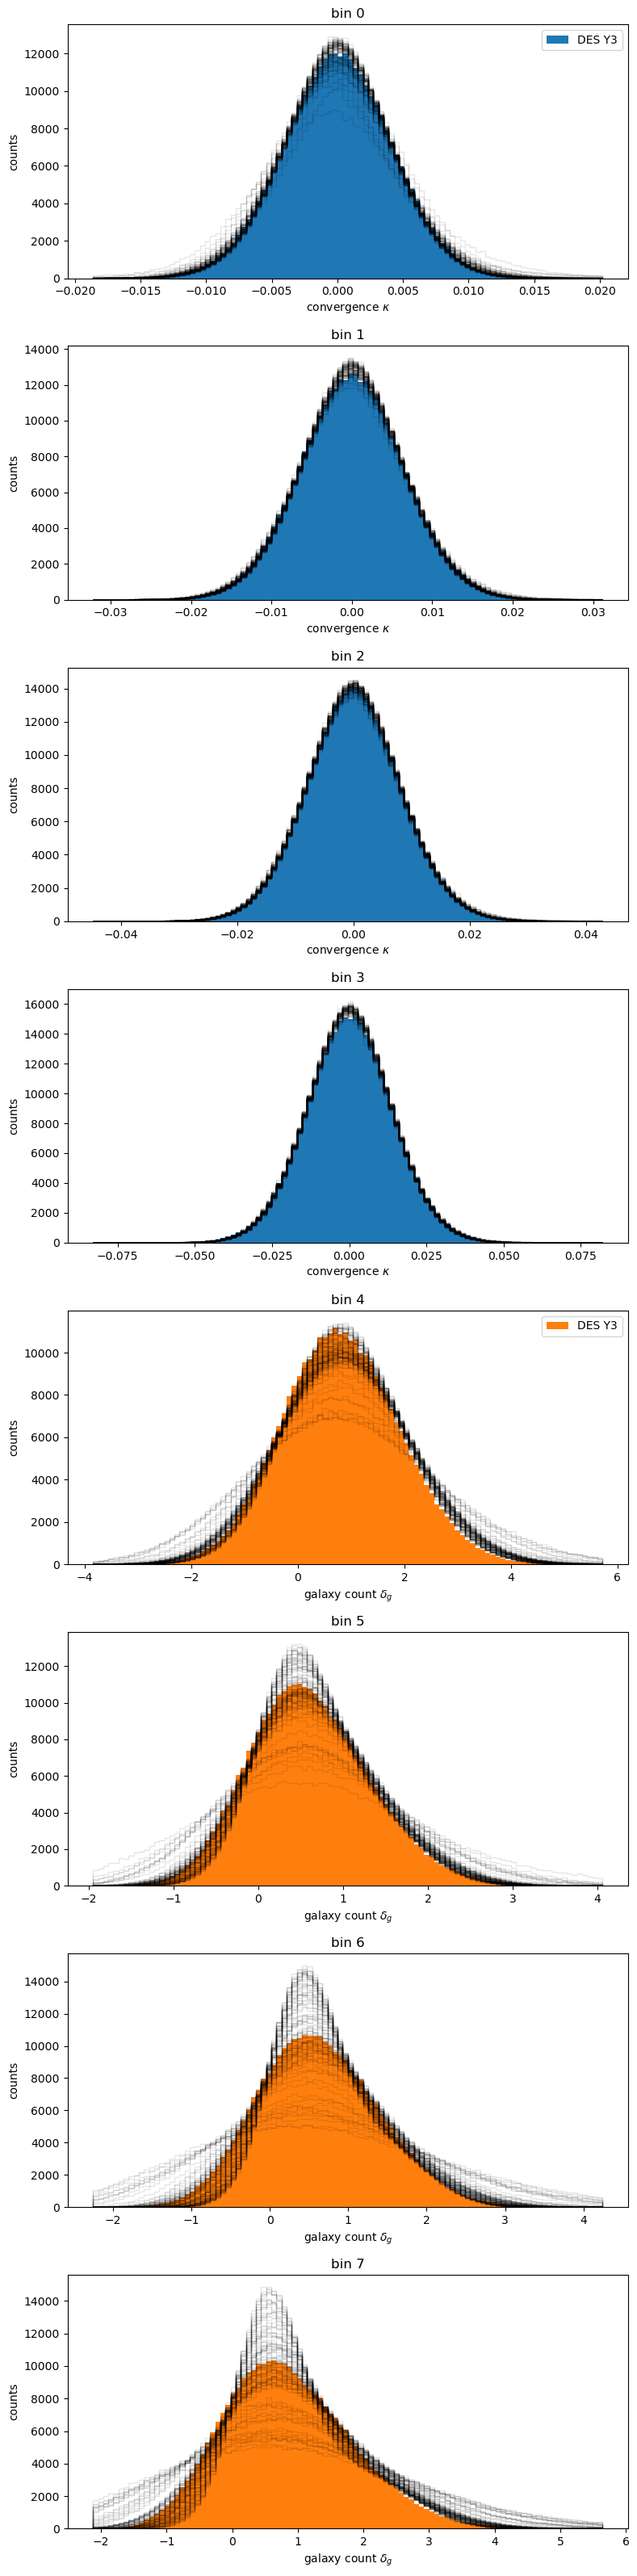

In [9]:
nrows = n_z
nplot = 100

fig, ax = plt.subplots(figsize=(8, 4 * nrows), nrows=nrows, sharex=False)
for i in range(nrows):
    des = obs_fp[:,i]
    _, bins = np.histogram(des, bins=100)

    if i < n_wl:
        color = "tab:blue"
        xlabel = r"convergence $\kappa$"
    else:
        color = "tab:orange"
        xlabel = r"galaxy count $\delta_g$"
    
    ax[i].hist(des, bins=bins, histtype="bar", color=color, label=obs_label)

    for j in range(nplot):
        grid = grid_fp[j,:,i]
        ax[i].hist(grid, bins=bins, histtype="step", alpha=0.1, color="k")

    ax[i].set(title=f"bin {i}",  ylabel="counts", xlabel=xlabel)

ax[0].legend()
ax[n_wl].legend()
fig.tight_layout()

# maps

In [10]:
# nrows = n_z
# ncols = 5

# fig = plt.figure(figsize=(8 * ncols, 4 * nrows))
# for i in range(nrows):
#     for j in range(ncols):
#         if j == 0:
#             hp_map = obs_map[:,i]
#         else:
#             hp_map = grid_map[j,:,i]

#         # probes
#         if i < n_wl:
#             cmap = "viridis"
#         else:
#             cmap = "plasma"
        
#         # title
#         if i == 0:
#             if j == 0:
#                 title = obs_label
#             else:
#                 title = f"CosmoGrid {j}"
#         else:
#             title = None
        
#         k = i * ncols + j + 1
        
#         hp.mollview(
#             hp_map,
#             sub=(nrows, ncols, k),
#             fig=fig.number,
#             title=title,
#             cmap=cmap,
#             nest=True,
#         )

# fig.tight_layout()


# moments

In [11]:
n_stats = 1_000
n_steps = n_stats // batch_size

grid_mean = np.zeros((n_stats,n_z))
grid_std = np.zeros((n_stats,n_z))
grid_skew = np.zeros((n_stats,n_z))
grid_kurt = np.zeros((n_stats,n_z))
for i, (dv, cl, cosmo, index) in tqdm(enumerate(grid_dset.take(n_steps))):
    dv = smoothing_layer(dv)

    fp = dv.numpy()[:,mask_dv]

    grid_mean[i*batch_size:(i+1)*batch_size] = np.mean(fp, axis=1)
    grid_std[i*batch_size:(i+1)*batch_size] = np.std(fp, axis=1)
    grid_skew[i*batch_size:(i+1)*batch_size] = stats.skew(fp, axis=1)
    grid_kurt[i*batch_size:(i+1)*batch_size] = stats.kurtosis(fp, axis=1)
    

100it [02:29,  1.50s/it]


In [12]:
obs_mean = np.mean(obs_fp, axis=0)
obs_std = np.std(obs_fp, axis=0)
obs_skew = stats.skew(obs_fp, axis=0)
obs_kurt = stats.kurtosis(obs_fp, axis=0)

[Text(0.5, 1.0, 'kurtosis')]

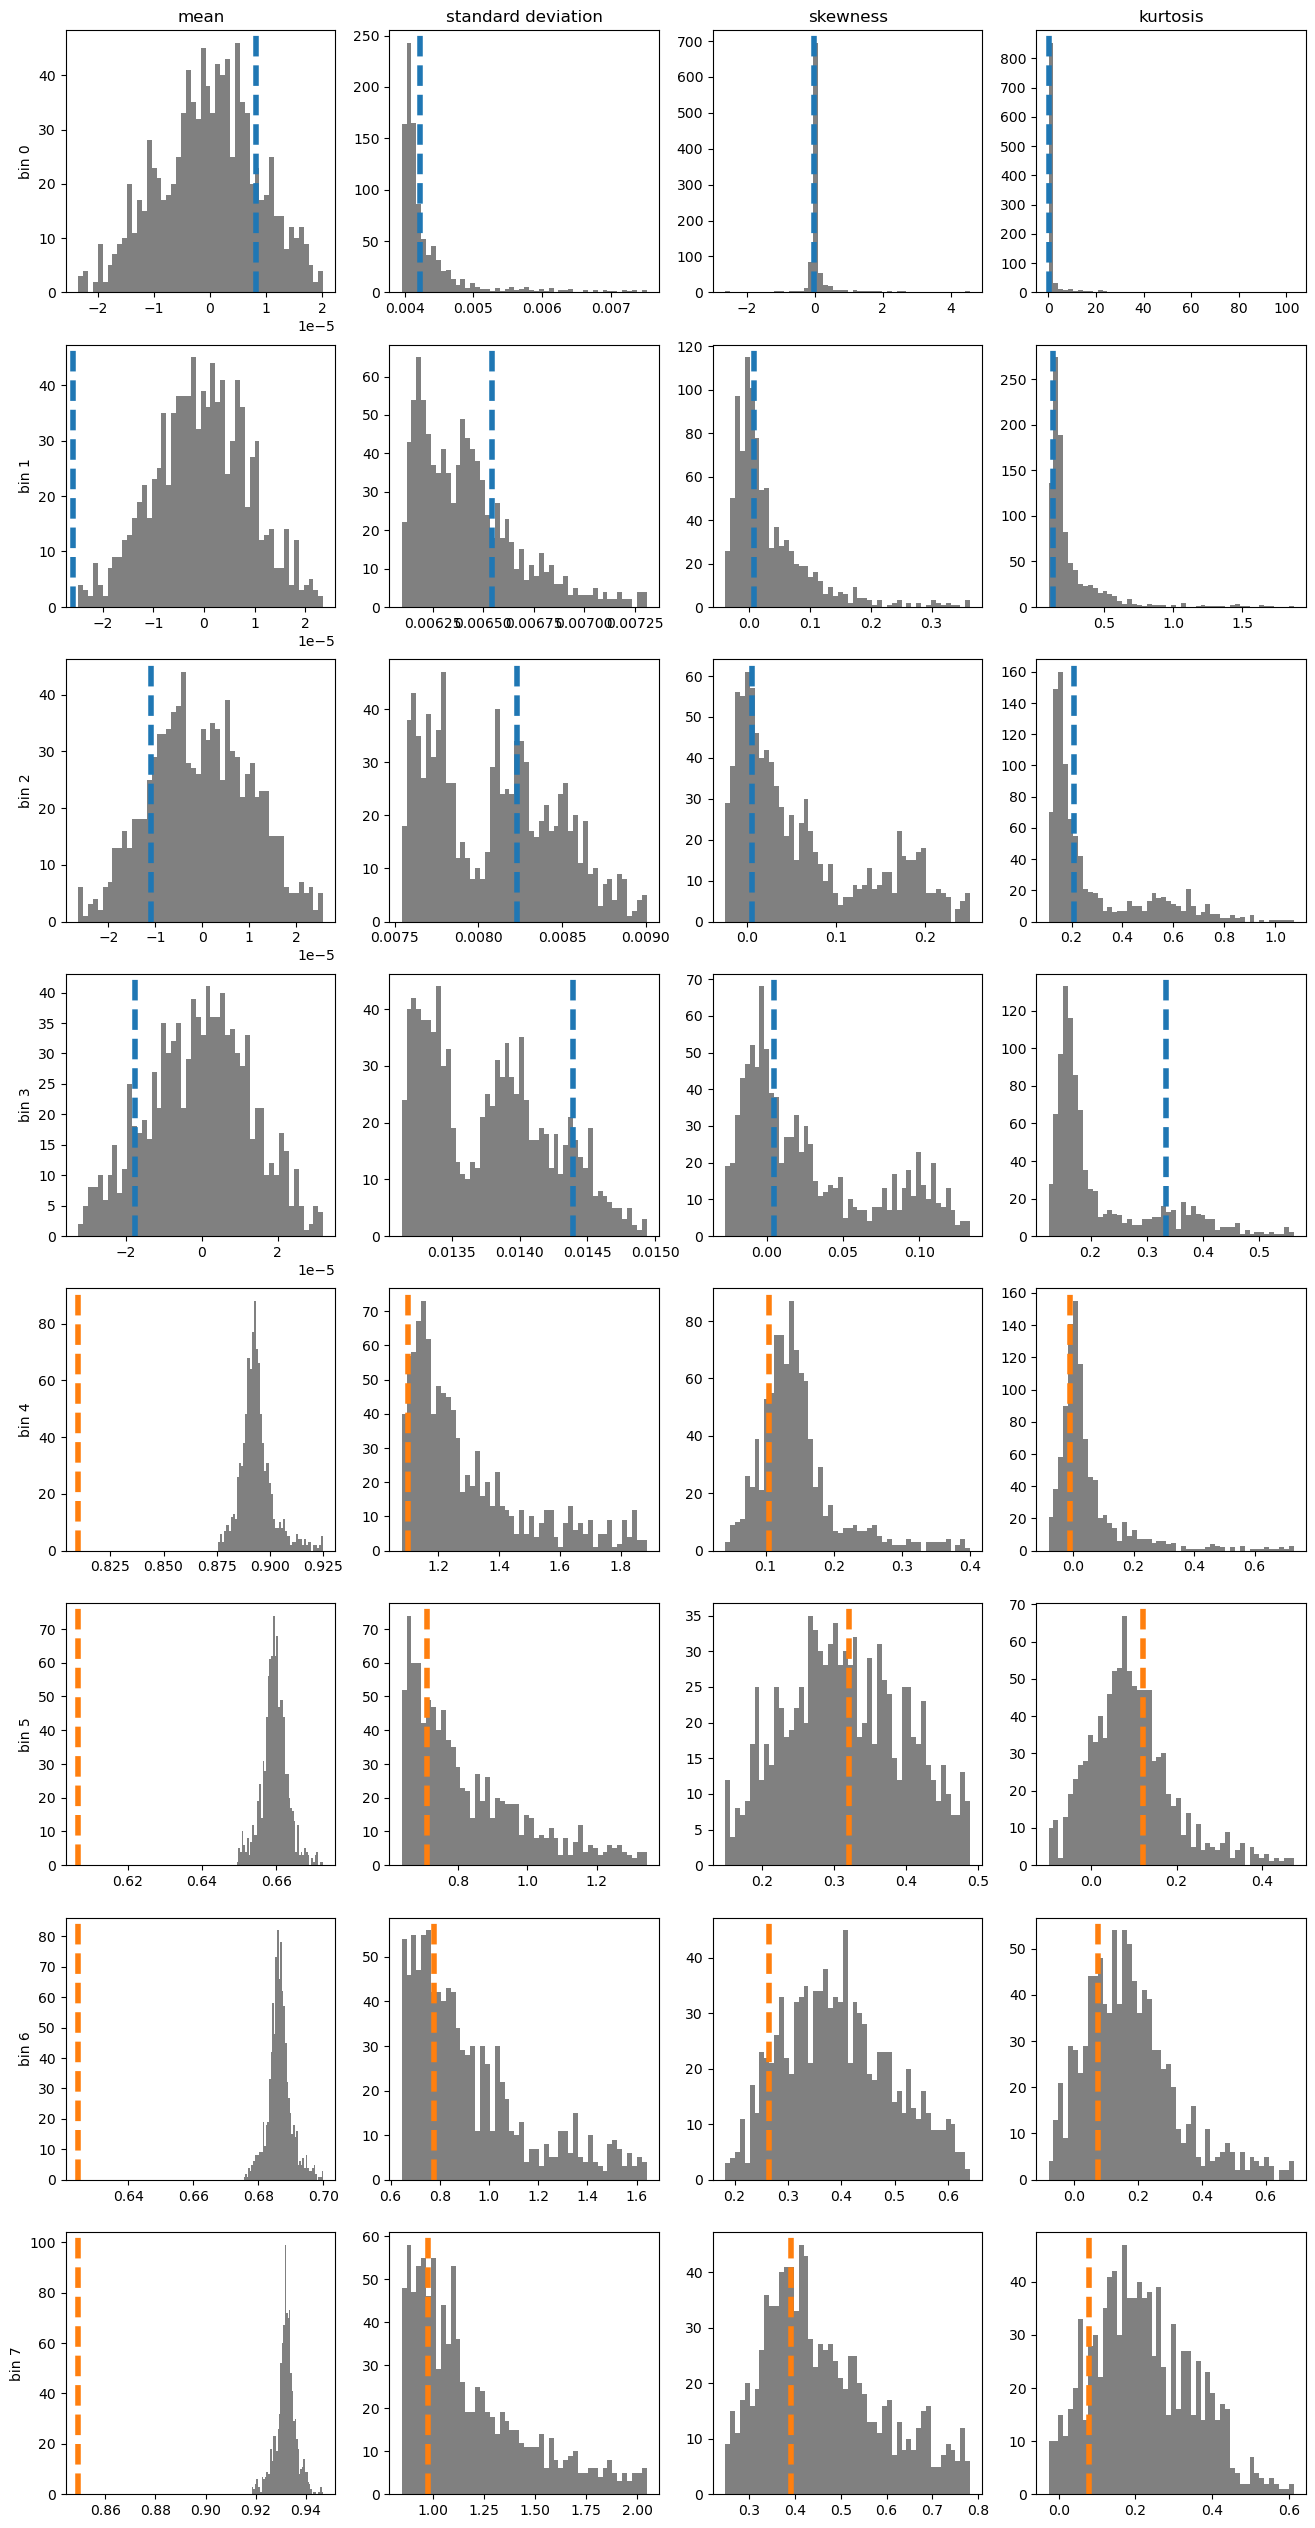

In [13]:
def robust_hist(ax, x, q_low=0.01, q_high=0.99):
    limits = np.quantile(x, [q_low, q_high], axis=0)
    ax.hist(x, range=limits, bins=n_stats//20, color="grey")

nrows = n_z
ncols = 4

fig, ax = plt.subplots(figsize=(4 * ncols, 4 * nrows), nrows=nrows, ncols=ncols)
for i in range(nrows):
    if i < n_wl:
        color = "tab:blue"
    else:
        color = "tab:orange"

    # mean
    robust_hist(ax[i,0], grid_mean[:,i])
    ax[i,0].axvline(obs_mean[i], linestyle="--", color=color, linewidth=4)

    # std
    robust_hist(ax[i,1], grid_std[:,i])
    ax[i,1].axvline(obs_std[i], linestyle="--", color=color, linewidth=4)
    
    # skew
    robust_hist(ax[i,2], grid_skew[:,i])
    ax[i,2].axvline(obs_skew[i], linestyle="--", color=color, linewidth=4)
    
    # kurtosis
    robust_hist(ax[i,3], grid_kurt[:,i])
    ax[i,3].axvline(obs_kurt[i], linestyle="--", color=color, linewidth=4)

    ax[i,0].set(ylabel=f"bin {i}")

ax[0,0].set(title="mean")
ax[0,1].set(title="standard deviation")
ax[0,2].set(title="skewness")
ax[0,3].set(title="kurtosis")

# trash